<a href="https://colab.research.google.com/github/Adityastack/ECG_Signal_Classification/blob/main/ECG_Signal_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ECG Signal Classification using Machine Learning


Data Loading and Preprocessing

In [8]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

def load_data(train_path, test_path):
    train_df = pd.read_csv(train_path, header=None)
    test_df = pd.read_csv(test_path, header=None)

    X_train = train_df.iloc[:, :-1].values
    y_train = train_df.iloc[:, -1].values
    X_test = test_df.iloc[:, :-1].values
    y_test = test_df.iloc[:, -1].values

    return X_train, y_train, X_test, y_test

def scale_data(X_train, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

def encode_labels(y_train, y_test):
    encoder = LabelEncoder()
    y_train_encoded = encoder.fit_transform(y_train)
    y_test_encoded = encoder.transform(y_test)
    return y_train_encoded, y_test_encoded

Model Building and Training

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

def build_model(input_dim, num_classes):
    model = Sequential([
        Dense(128, input_shape=(input_dim,), activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def train_model(model, X_train, y_train, epochs=30, batch_size=64, validation_split=0.2):
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=validation_split)
    return history

Model Evaluation

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

def evaluate_model(model, X_test, y_test):
    loss, accuracy = model.evaluate(X_test, y_test)
    print(f"Test Accuracy: {accuracy*100:.2f}%")

    y_pred = np.argmax(model.predict(X_test), axis=1)
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:\n")
    print(confusion_matrix(y_test, y_pred))

Plotting Training Curves

In [11]:
import matplotlib.pyplot as plt

def plot_history(history):
    # Plot training & validation accuracy values
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train','Validation'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train','Validation'], loc='upper right')
    plt.show()

Full Pipeline Execution

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 654ms/step - accuracy: 0.4230 - loss: 0.9965 - val_accuracy: 0.9778 - val_loss: nan
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9468 - loss: 0.2259 - val_accuracy: 0.9889 - val_loss: nan
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 1.0000 - loss: 0.0700 - val_accuracy: 0.9889 - val_loss: nan
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 0.0278 - val_accuracy: 0.9889 - val_loss: nan
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.0143 - val_accuracy: 0.9889 - val_loss: nan
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0086 - val_accuracy: 0.9889 - val_loss: nan
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.0071 - val_accuracy: 0.9889 - val_loss: nan
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.0060 - val_accuracy: 0.9889 - val_loss: nan
Epoch 9/30
6/6 ━━━━━━━━

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


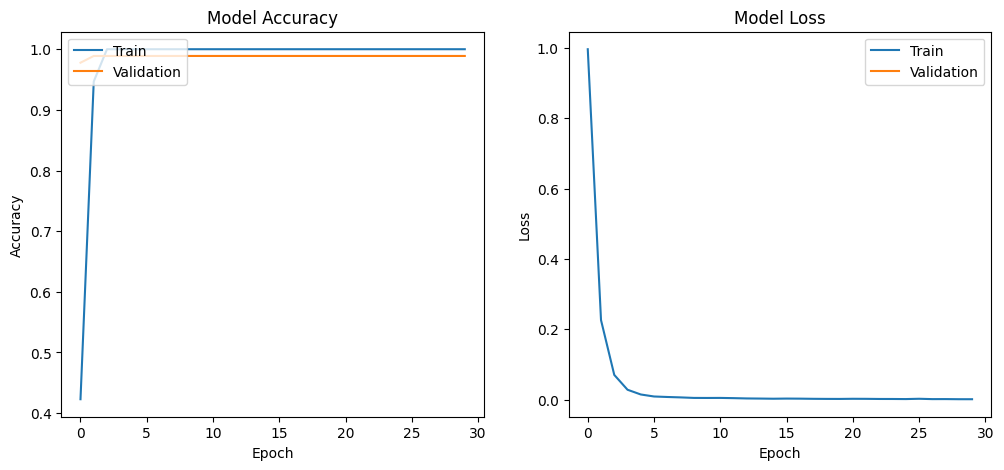

In [12]:
# -----------------------------
# ECG Classification Notebook
# -----------------------------

# 1. Import Libraries
# The functions are already defined in the notebook cells above, no need to import from local files
# import sys
# sys.path.append('../src')    # To import our scripts

# from data_preprocessing import load_data, scale_data, encode_labels
# from train_model import build_model, train_model
# from evaluate_model import evaluate_model
# from utils import plot_history


# 2. Load Data
X_train, y_train, X_test, y_test = load_data('/content/mitbih_train.csv', '/content/mitbih_test.csv')


# 3. Preprocess Data
X_train, X_test = scale_data(X_train, X_test)
y_train, y_test = encode_labels(y_train, y_test)


# 4. Build Model
num_classes = len(set(y_train))
model = build_model(input_dim=X_train.shape[1], num_classes=num_classes)


# 5. Train Model
history = train_model(model, X_train, y_train, epochs=30, batch_size=64)


# 6. Evaluate Model
evaluate_model(model, X_test, y_test)


# 7. Plot Training History
plot_history(history)


# 8. Save Model
model.save('../models/ecg_model.h5')